## Notebook for data examination after clustering

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import pandas as pd
from pandas.plotting import scatter_matrix
import seaborn as sns
import os

from tqdm import tqdm

import hdbscan

from scipy.spatial.distance import cdist

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import r2_score, silhouette_score#, calinski_harabasz_score, davies_bouldin_score

from sklearn.manifold import TSNE

from sklearn.cluster import DBSCAN
from sklearn.cluster import SpectralClustering
from sklearn.cluster import AgglomerativeClustering

import plotly.express as px
import plotly.graph_objects as go

In [2]:
# import the merged data file
merged_df = pd.read_csv('fusion_results_merged_with_clusters.csv.gzip', compression='gzip', sep=',', header=0, dtype={'# sample': str, 'Depth': str})
merged_df.head()

,Mg,Al,Si,K,Ca,Ti,Mn,Fe,Rb,Sr,...,Mn mole fraction,Fe mole fraction,Rb mole fraction,Sr mole fraction,Zr mole fraction,Ba mole fraction,La mole fraction,Ce mole fraction,U mole fraction,Agglomerative Cluster
0,0.0,0.0000,0.0,0.0,0.0,0.000,0.0,4364.6397,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
1,0.0,3359.1233,0.0,0.0,0.0,0.000,0.0,0.0000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,0.0,0.0000,0.0,0.0,0.0,0.000,0.0,2334.2033,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
3,0.0,0.0000,0.0,0.0,0.0,48093.213,0.0,0.0000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
4,0.0,0.0000,0.0,0.0,0.0,0.000,0.0,0.0000,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0


In [3]:
# Calculate the mean and standard deviation for each cluster
def calculate_cluster_stats(dataframe, cluster_col=['Agglomerative Cluster']):
    numeric_df = dataframe.select_dtypes(include='number').copy()
    numeric_df[cluster_col[0]] = dataframe[cluster_col[0]].values
    stats = numeric_df.groupby(cluster_col).agg(['mean', 'std'])
    return stats

# Compute stats for clusters and for samples
cluster_stats = calculate_cluster_stats(merged_df, cluster_col=['Agglomerative Cluster'])
sample_stats = calculate_cluster_stats(merged_df, cluster_col=['# sample'])

# Compute cluster sizes
size_clusters = merged_df['Agglomerative Cluster'].value_counts()
size_clusters.sort_index(inplace=True)

size_clusters_df = pd.DataFrame(size_clusters).reset_index()
size_clusters_df.columns = ['Agglomerative Cluster', 'Number']
size_clusters_df['Fraction'] = size_clusters_df['Number'] / size_clusters_df['Number'].sum() * 100

# Compute total mass per cluster and merge it
total_mass = merged_df.groupby('Agglomerative Cluster')['Sum'].sum().reset_index()
size_clusters_df = pd.merge(size_clusters_df, total_mass, on='Agglomerative Cluster')
size_clusters_df.rename(columns={'Sum': 'Total mass'}, inplace=True)

# Create a sentence column for plotting or reporting
size_clusters_df['Sentence'] = size_clusters_df.apply(
    lambda row: f"Cluster {int(row['Agglomerative Cluster'])}\nn = {int(row['Number'])}\n({row['Fraction']:.1f}%)",
    axis=1
)

# Preview the result
size_clusters_df.head()

,Agglomerative Cluster,Number,Fraction,Total mass,Sentence
0,0,18695,4.495579,1.755022e+08,Cluster 0\nn = 18695\n(4.5%)
1,1,40737,9.796010,5.834787e+08,Cluster 1\nn = 40737\n(9.8%)
2,2,36745,8.836055,6.597490e+09,Cluster 2\nn = 36745\n(8.8%)
3,3,21245,5.108776,1.658659e+08,Cluster 3\nn = 21245\n(5.1%)
4,4,204929,49.279192,1.171193e+09,Cluster 4\nn = 204929\n(49.3%)


In [4]:
# read the elements.txt file to save the elements
df_elements = pd.read_csv('Add_data/elements.txt', sep='\t', header=None, names=['Element'])
# Convert the elements DataFrame to a list
elements = df_elements['Element'].tolist()

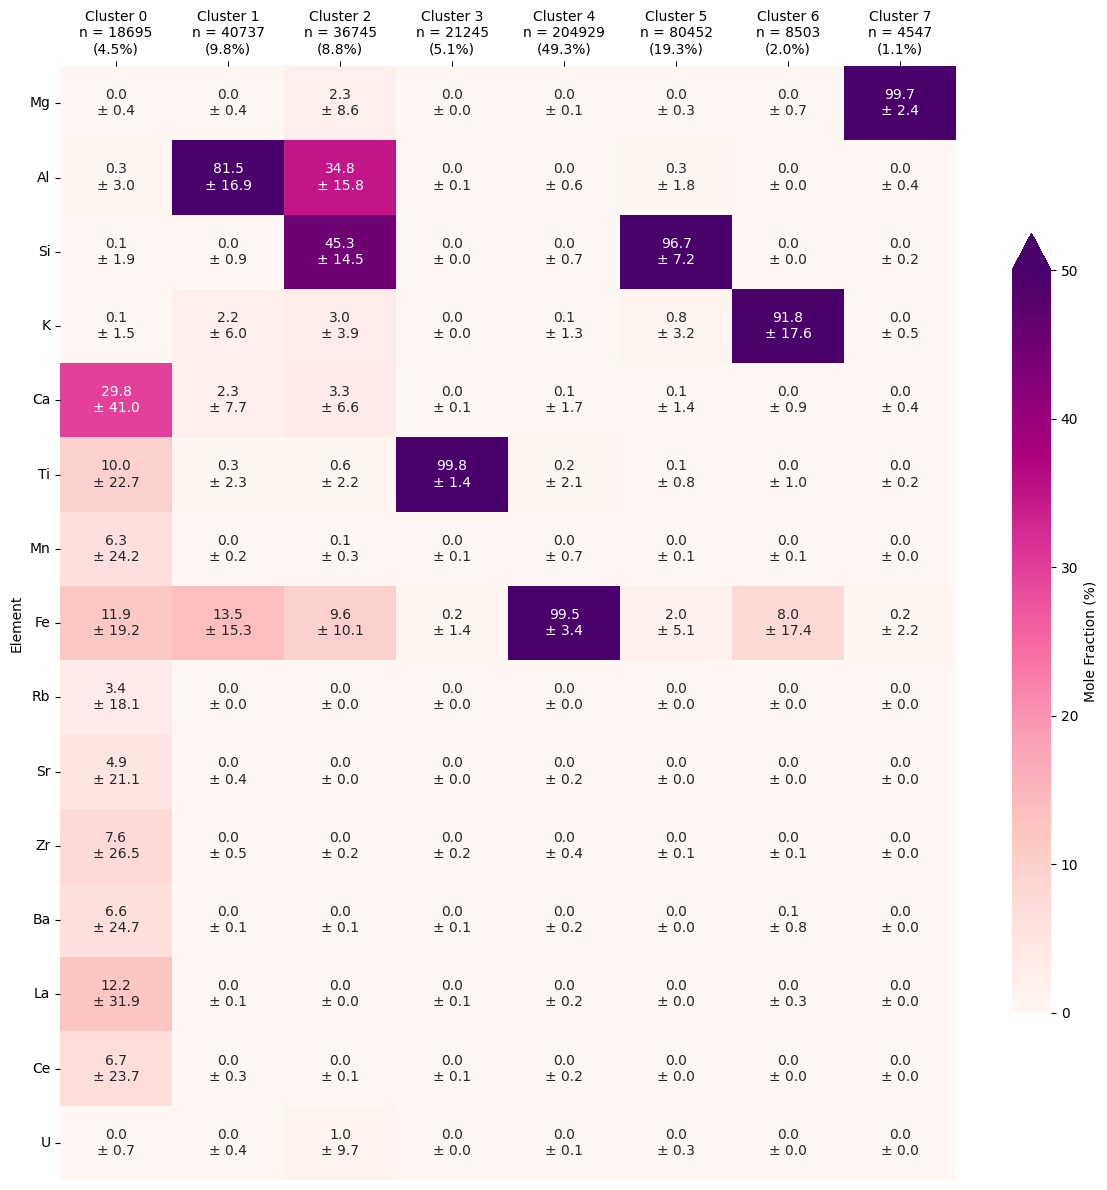

In [5]:
# Select column "mass fraction"
mole_fraction_cols = [col for col in cluster_stats.columns if col[0].endswith('mole fraction')]

# Extract mean & std
means = cluster_stats[mole_fraction_cols].xs('mean', axis=1, level=1) * 100
stds = cluster_stats[mole_fraction_cols].xs('std', axis=1, level=1) * 100

# Creat an annotation matrice
annot = means.round(1).astype(str) + "\n± " + stds.round(1).astype(str)

# Plot heatmap
plt.figure(figsize=(12, 12))
ax = sns.heatmap(
    means.T,
    annot=annot.T,
    fmt="",
    cmap='RdPu', vmin=0, vmax=50,
    cbar_kws={'label': 'Mole Fraction (%)', "shrink": 0.7, 'extend': 'max', 'extendrect': False},
    xticklabels=size_clusters_df['Sentence'], yticklabels=elements
)

plt.yticks(rotation=0)
plt.xticks(rotation=0)
ax.xaxis.tick_top()
plt.ylabel('Element')
plt.xlabel('')
plt.tight_layout()
plt.savefig("Figures/cluster_compo_moles.png", dpi=300, bbox_inches='tight')
plt.show()

/var/folders/zk/2_bksjhn0g731cln_7qgt3q00000gn/T/ipykernel_89015/1942680791.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('plasma', stacked_df.shape[1])  # choose a colormap with enough distinct colors


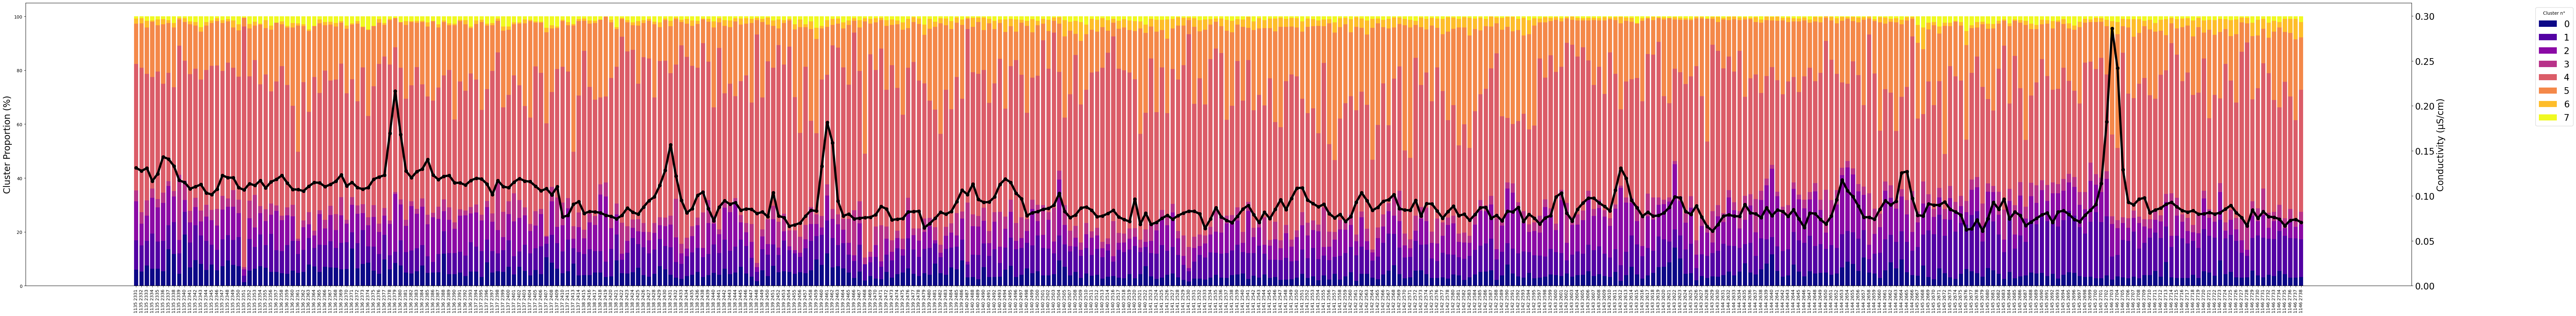

In [6]:
# Calculate the proportion of each cluster per sample
count_df = merged_df.groupby(['Filename', 'Agglomerative Cluster']).size().reset_index(name='Count')

# Calculate the total number of clusters per sample
total_df = merged_df.groupby('Filename').size().reset_index(name='Total')

# Merge the two DataFrames to get the proportion
proportion_df = pd.merge(count_df, total_df, on='Filename')
proportion_df['Proportion'] = 100 * proportion_df['Count'] / proportion_df['Total']

# Prepare the data (pivot so each cluster becomes a column)
stacked_df = proportion_df.pivot(index='Filename', columns='Agglomerative Cluster', values='Proportion').fillna(0)

# Plot
fig, ax = plt.subplots(figsize=(80, 10))

bottom = None  # to stack bars on top of each other
colors = plt.cm.get_cmap('plasma', stacked_df.shape[1])  # choose a colormap with enough distinct colors

for i, cluster in enumerate(stacked_df.columns):
    ax.bar(
        stacked_df.index,
        stacked_df[cluster],
        bottom=bottom,
        label=cluster,
        color=colors(i)
    )
    # Update bottom for next cluster
    bottom = stacked_df[cluster] if bottom is None else bottom + stacked_df[cluster]

# Formatting
ax.set_ylabel("Cluster Proportion (%)", fontsize=20)
ax.set_xticks(range(len(stacked_df.index)))
ax.set_xticklabels(stacked_df.index, rotation=90)
ax.legend(title="Cluster n°", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=20)

# add a twin y-axis for the conductivity
ax2 = ax.twinx()
# Compute mean conductivity per sample
cond_df = merged_df.groupby('Filename')['Conductivity'].mean().reindex(stacked_df.index)

# Plot conductivity per sample
ax2.plot(
    cond_df.index,
    cond_df.values,
    color='black',
    marker='o',
    label='Conductivity (µS/cm)',
    markersize=7,
    linewidth=5
)
# Set the y-axis label for conductivity
ax2.set_ylabel('Conductivity (µS/cm)', fontsize=20)
# Set the y-axis limits for conductivity
ax2.set_ylim(0, merged_df['Conductivity'].max() * 1.1)

# # Increase y-ticks fontsize
plt.yticks(fontsize=20)
plt.xticks(fontsize=20)
plt.tight_layout()
plt.savefig("Figures/cluster_proportions.png", dpi=300, bbox_inches='tight')
plt.show()

In [7]:
def ternary_plot(dataframe, var1, var2, var3, var4='Cluster'):
    # Rename cluster values to "Cluster X"
    dataframe[var4] = dataframe[var4].apply(lambda x: f"Cluster {x}")

    fig = px.scatter_ternary(
        dataframe,
        a=var1, b=var2, c=var3,
        color=var4,
        color_continuous_scale=px.colors.sequential.Viridis,
        size='Sum',
        size_max=50
    )

    # Update ternary axis titles and styling
    fig.update_ternaries(
        aaxis_title_text=var1, baxis_title_text=var2, caxis_title_text=var3,
        aaxis_title=dict(font_size=20, font_color='black'),
        baxis_title=dict(font_size=20, font_color='black'),
        caxis_title=dict(font_size=20, font_color='black'),
        aaxis_linecolor='black', baxis_linecolor='black', caxis_linecolor='black',
        aaxis_ticks='outside', baxis_ticks='outside', caxis_ticks='outside',
        aaxis_gridcolor='lightgrey', baxis_gridcolor='lightgrey', caxis_gridcolor='lightgrey',
        bgcolor='white'
    )

    fig.update_coloraxes(colorbar_title_font=dict(size=15))

    # Remove legend title and adjust legend position
    fig.update_layout(
        legend=dict(title_text='', x=0.8, y=0.8),
        width=1200,  # Increased width for better visibility
        height=1200,  # Increased height for better visibility
        margin=dict(l=50, r=50, t=50, b=50),  # Added margins
        font=dict(size=16)  # Increased font size for better readability
    )

    # Add reference mineral points
    fig.add_trace(go.Scatterternary(a=[0.47],b=[0.52],c=[0.01],mode="markers",marker=dict(symbol='square', color='blue', size=20), name='Kaolinite'))
    fig.add_trace(go.Scatterternary(a=[0.35],b=[0.55],c=[0.10],mode="markers",marker=dict(symbol='square', color='black', size=20), name='Illite'))
    fig.add_trace(go.Scatterternary(a=[0.25],b=[0.40],c=[0.35],mode="markers",marker=dict(symbol='square', color='orange', size=20), name='Chlorite'))
    fig.add_trace(go.Scatterternary(a=[0.23],b=[0.65],c=[0.12],mode="markers",marker=dict(symbol='cross', color='firebrick', size=20), name='Basaltic glass'))
    fig.add_trace(go.Scatterternary(a=[0.17],b=[0.80],c=[0.03],mode="markers",marker=dict(symbol='cross', color='green', size=20), name='Rhyolitic glass'))

    # Save the figure
    fig.write_image(f"Figures/ternary_plot_{var1}-{var2}-{var3}.png", scale=2)  # Removed dpi argument


In [8]:
cluster_number = [0,2,3,7]
#cluster_number = [1,2,5]  # Specify the cluster number you want to plot

# extract only data for the elements Al, Si, and Fe mole fraction for cluster 1,2,6
data_tern = merged_df[(merged_df['Agglomerative Cluster'].isin(cluster_number)) & (merged_df['Sum'] > 0)].copy()  # Filter for clusters 0, 3, and 8 and Sum > 0
# Select only the relevant columns for the ternary plot
data_tern = data_tern[['Al mole fraction', 'Si mole fraction', 'Fe mole fraction', 'Agglomerative Cluster', 'Sum']]
# Rename columns for clarity in the ternary plot
data_tern.rename(columns={
    'Al mole fraction': 'Al',
    'Si mole fraction': 'Si',
    'Fe mole fraction': 'Fe'
}, inplace=True)
# Ensure the 'Cluster' column is categorical for better color mapping
data_tern['Agglomerative Cluster'] = data_tern['Agglomerative Cluster'].astype('category')
# Ensure the 'Sum' column is numeric for size scaling
data_tern['Sum'] = pd.to_numeric(data_tern['Sum'], errors='coerce')
# Remove rows with NaN values in the ternary plot data
#data_tern.dropna(subset=['Al', 'Si', 'Fe', 'Sum'], inplace=True)

# plot ternary plot of the NP data

ternary_plot(data_tern, 'Al', 'Si', 'Fe', 'Agglomerative Cluster')

In [9]:
# plot a ternary plot of the NP data with the elements La, Ce and Sr
data_tern = merged_df[(merged_df['Agglomerative Cluster'].isin([0])) & (merged_df['Sum'] > 0)].copy()  # Filter for clusters 0 and Sum > 0
# Select only the relevant columns for the ternary plot
data_tern = data_tern[['La mole fraction', 'Ce mole fraction', 'Sr mole fraction', 'Agglomerative Cluster', 'Sum']]
# Rename columns for clarity in the ternary plot
data_tern.rename(columns={
    'La mole fraction': 'La',
    'Ce mole fraction': 'Ce',
    'Sr mole fraction': 'Sr'
}, inplace=True)
# Ensure the 'Cluster' column is categorical for better color mapping
data_tern['Agglomerative Cluster'] = data_tern['Agglomerative Cluster'].astype('category')
# Ensure the 'Sum' column is numeric for size scaling
data_tern['Sum'] = pd.to_numeric(data_tern['Sum'], errors='coerce')
# Remove rows with NaN values in the ternary plot data
#data_tern.dropna(subset=['La', 'Ce', 'Sr', 'Sum'], inplace=True)

# plot ternary plot of the NP data
ternary_plot(data_tern, 'La', 'Ce', 'Sr', 'Agglomerative Cluster')

/var/folders/zk/2_bksjhn0g731cln_7qgt3q00000gn/T/ipykernel_89015/2943798374.py:3: UserWarning:


The markers list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.



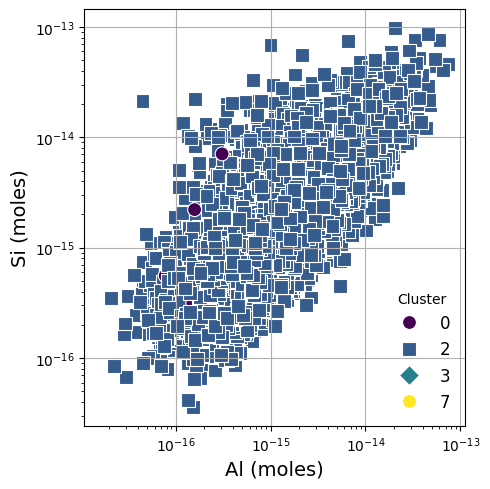

In [10]:
# plot Al vs Si scatter plot for clusters 1,2,6 using the moles
plt.figure(figsize=(5, 5))
sns.scatterplot(
    data=merged_df[merged_df['Agglomerative Cluster'].isin(cluster_number)],
    x='Al moles', y='Si moles',
    hue='Agglomerative Cluster', style='Agglomerative Cluster',
    palette='viridis', markers=['o', 's', 'D'], s=100
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Al (moles)', fontsize=14)
plt.ylabel('Si (moles)', fontsize=14)
plt.legend(title='Cluster', fontsize=12, frameon=False)
plt.grid(True)
plt.tight_layout()

plt.savefig("Figures/Al_Si_scatter.png", dpi=300, bbox_inches='tight')
plt.show()


/var/folders/zk/2_bksjhn0g731cln_7qgt3q00000gn/T/ipykernel_89015/1018724866.py:3: UserWarning:


The markers list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.



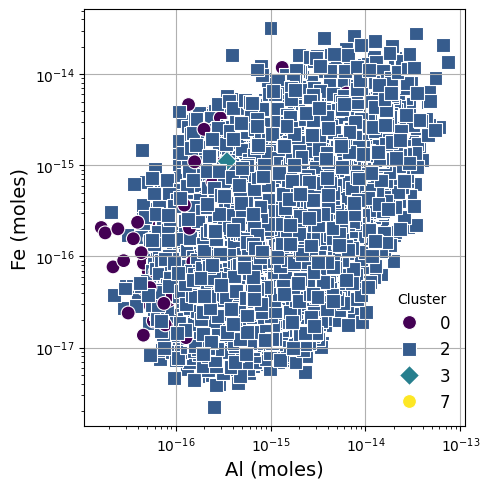

In [11]:
# plot Al vs Fe scatter plot for clusters 1,2,6 using the moles
plt.figure(figsize=(5, 5))
sns.scatterplot(
    data=merged_df[merged_df['Agglomerative Cluster'].isin(cluster_number)],
    x='Al moles', y='Fe moles',
    hue='Agglomerative Cluster', style='Agglomerative Cluster',
    palette='viridis', markers=['o', 's', 'D'], s=100
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Al (moles)', fontsize=14)
plt.ylabel('Fe (moles)', fontsize=14)
plt.legend(title='Cluster', fontsize=12, frameon=False)
plt.grid(True)
plt.tight_layout()

plt.savefig("Figures/Al_Fe_scatter.png", dpi=300, bbox_inches='tight')
plt.show()


/var/folders/zk/2_bksjhn0g731cln_7qgt3q00000gn/T/ipykernel_89015/3689132018.py:3: UserWarning:


The markers list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.



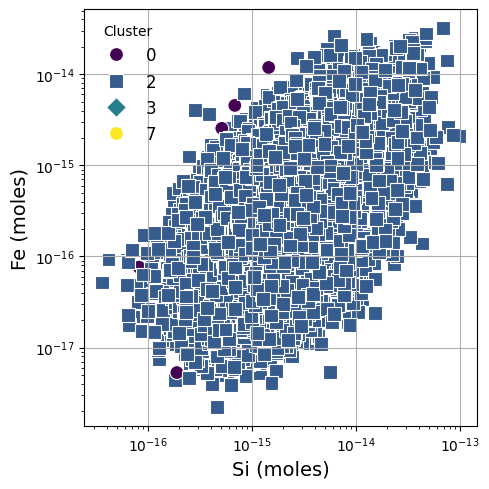

In [12]:
# plot Si vs Fe scatter plot for clusters 1,2,6 using the moles
plt.figure(figsize=(5, 5))
sns.scatterplot(
    data=merged_df[merged_df['Agglomerative Cluster'].isin(cluster_number)],
    x='Si moles', y='Fe moles',
    hue='Agglomerative Cluster', style='Agglomerative Cluster',
    palette='viridis', markers=['o', 's', 'D'], s=100
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Si (moles)', fontsize=14)
plt.ylabel('Fe (moles)', fontsize=14)
plt.legend(title='Cluster', fontsize=12, frameon=False)
plt.grid(True)
plt.tight_layout()

plt.savefig("Figures/Si_Fe_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

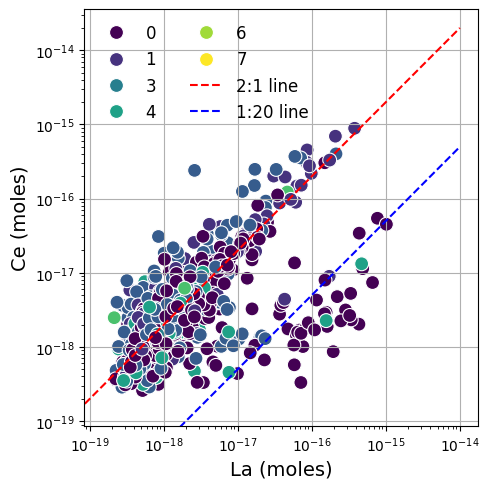

In [13]:
# plot La vs Ce scatter plot for cluster 7 using the moles
plt.figure(figsize=(5, 5))
sns.scatterplot(
    data=merged_df,#[merged_df['Agglomerative Cluster'] == 5],
    x='La moles', y='Ce moles',
    hue='Agglomerative Cluster',# style='Agglomerative Cluster',
    palette='viridis', markers=['o'], s=100
)

# add a 2:1 line to the plot
x = np.linspace(0, 1e-14, 100)
plt.plot(x, x * 2, color='red', linestyle='--', label='2:1 line')
plt.plot(x, x * 0.05, color='blue', linestyle='--', label='1:20 line')


plt.xscale('log')
plt.yscale('log')
plt.xlabel('La (moles)', fontsize=14)
plt.ylabel('Ce (moles)', fontsize=14)
plt.legend(fontsize=12, frameon=False, ncol=2, loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.savefig("Figures/La_Ce_scatter.png", dpi=300, bbox_inches='tight')

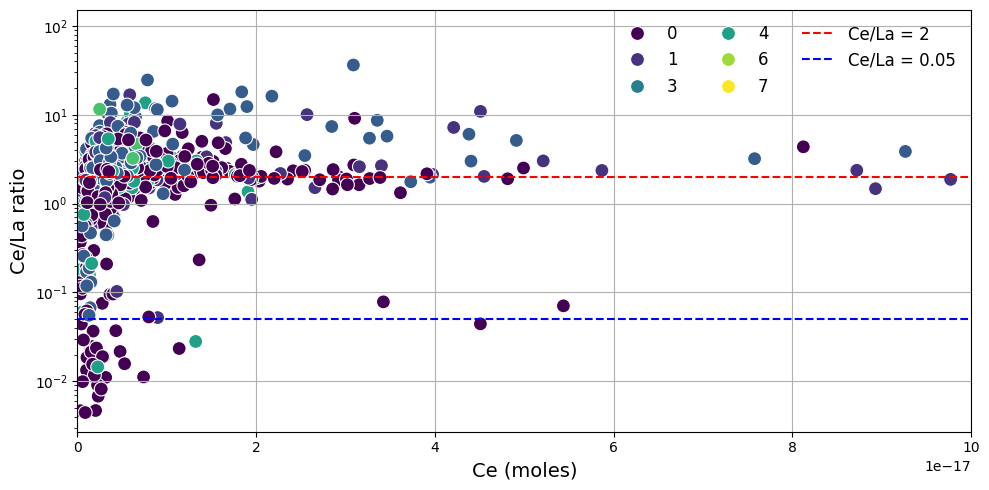

In [14]:
# plot the molar ratio Ce/La vs Ce moles

# calculate the Ce/La ratio
merged_df['Ce/La ratio'] = merged_df['Ce moles'] / merged_df['La moles']

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=merged_df,
    x='Ce moles', y='Ce/La ratio',
    hue='Agglomerative Cluster',# style='Agglomerative Cluster',
    palette='viridis', markers=['o'], s=100
)

plt.axhline(y=2, color='red', linestyle='--', label='Ce/La = 2')
plt.axhline(y=0.05, color='blue', linestyle='--', label='Ce/La = 0.05')
#plt.xscale('log')
plt.yscale('log')
plt.xlim(-0, 1e-16)  # Set x-axis limit to avoid extreme values
plt.xlabel('Ce (moles)', fontsize=14)
plt.ylabel('Ce/La ratio', fontsize=14)
plt.legend(fontsize=12, frameon=False, ncol=3)#, loc='upper left')
plt.grid(True)
plt.tight_layout()
#plt.savefig("Figures/Ce_CeLa_ratio_scatter.png", dpi=300, bbox_inches='tight')

In [15]:
"""# plot all elements vs all elements
matrix_cols = [col for col in merged_df.columns if col.endswith('moles')] #and col != 'Sum']
plt.figure(figsize=(12, 12))
sns.pairplot(
    merged_df[matrix_cols + ['Agglomerative Cluster']],
    hue='Agglomerative Cluster',
    palette='viridis',
    markers=['o', 's', 'D'],  # Only using filled markers
    plot_kws={'alpha': 0.5, 's': 50}
)
plt.suptitle('Pairplot of Element Moles by Cluster', fontsize=20)
#plt.savefig("Figures/pairplot_elements_moles.png", dpi=300, bbox_inches='tight')
#plt.show()"""

'# plot all elements vs all elements\nmatrix_cols = [col for col in merged_df.columns if col.endswith(\'moles\')] #and col != \'Sum\']\nplt.figure(figsize=(12, 12))\nsns.pairplot(\n    merged_df[matrix_cols + [\'Agglomerative Cluster\']],\n    hue=\'Agglomerative Cluster\',\n    palette=\'viridis\',\n    markers=[\'o\', \'s\', \'D\'],  # Only using filled markers\n    plot_kws={\'alpha\': 0.5, \'s\': 50}\n)\nplt.suptitle(\'Pairplot of Element Moles by Cluster\', fontsize=20)\n#plt.savefig("Figures/pairplot_elements_moles.png", dpi=300, bbox_inches=\'tight\')\n#plt.show()'